In [105]:
import pandas as pd
import os
import matplotlib.pyplot as plt



df = pd.read_csv(r'C:\Users\thlam\Downloads\Real_Estate_Sales_2001-2022_GL.csv', low_memory=False)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
print(df.head())




   Serial Number  List Year Date Recorded     Town          Address  \
0        2020177       2020    04/14/2021  Ansonia    323 BEAVER ST   
1        2020225       2020    05/26/2021  Ansonia   152 JACKSON ST   
2        2020348       2020    09/13/2021  Ansonia  230 WAKELEE AVE   
3        2020090       2020    12/14/2020  Ansonia      57 PLATT ST   
4         210288       2021    06/20/2022     Avon   12 BYRON DRIVE   

   Assessed Value  Sale Amount  Sales Ratio Property Type Residential Type  \
0        133000.0     248400.0       0.5354   Residential    Single Family   
1        110500.0     239900.0       0.4606   Residential     Three Family   
2        150500.0     325000.0       0.4630    Commercial              NaN   
3        127400.0     202500.0       0.6291   Residential       Two Family   
4        179990.0     362500.0       0.4965   Residential            Condo   

  Non Use Code Assessor Remarks OPM remarks  \
0          NaN              NaN         NaN   
1         

In [106]:
print(df.describe())
df.columns

       Serial Number     List Year  Assessed Value   Sale Amount   Sales Ratio
count   1.097629e+06  1.097629e+06    1.097629e+06  1.097629e+06  1.097629e+06
mean    5.370357e+05  2.011218e+03    2.818016e+05  4.053146e+05  9.603926e+00
std     7.526074e+06  6.773485e+00    1.657890e+06  5.143492e+06  1.801664e+03
min     0.000000e+00  2.001000e+03    0.000000e+00  0.000000e+00  0.000000e+00
25%     3.071300e+04  2.005000e+03    8.909000e+04  1.450000e+05  4.778667e-01
50%     8.070600e+04  2.011000e+03    1.405800e+05  2.330000e+05  6.105663e-01
75%     1.703410e+05  2.018000e+03    2.282700e+05  3.750000e+05  7.707200e-01
max     2.000500e+09  2.022000e+03    8.815100e+08  5.000000e+09  1.226420e+06


Index(['Serial Number', 'List Year', 'Date Recorded', 'Town', 'Address',
       'Assessed Value', 'Sale Amount', 'Sales Ratio', 'Property Type',
       'Residential Type', 'Non Use Code', 'Assessor Remarks', 'OPM remarks',
       'Location'],
      dtype='object')

In [107]:
total_transactions = df.shape[0]

total_market_value = df['Sale Amount'].sum()

average_sale_price = df['Sale Amount'].mean()

median_sale_price = df['Sale Amount'].median()
print('Total Market Value is:' ,total_market_value)
print('Average Sale Price is:',average_sale_price)
print('Median Sale Price is:',median_sale_price)

Total Market Value is: 444885014916.9099
Average Sale Price is: 405314.559761914
Median Sale Price is: 233000.0


In [109]:
# Convert Date Recorded to datetime
df['Date Recorded'] = pd.to_datetime(
    df['Date Recorded'],
    format='%m/%d/%Y',
    errors='coerce'
)

# Remove sales recorded before 2001
df_clean = df[
    df['Date Recorded'].dt.year >= 2001
].copy()

# Replace missing property classifications
df_clean['Property Type'] = (
    df_clean['Property Type']
    .fillna('Unknown')
)

df_clean['Residential Type'] = (
    df_clean['Residential Type']
    .fillna('Unknown')
)


            Town  Total_Sales   Average_Sale
0  ***Unknown***            1  282450.000000
1        Andover          932  227606.352961
2        Ansonia         5017  215572.956211
3        Ashford         1467  210955.159530
4           Avon         7866  476632.649071
5    Barkhamsted         1191  229630.722217
6   Beacon Falls         2034  282565.448869
7         Berlin         6030  294715.840690
8        Bethany         1799  313015.926070
9         Bethel         6004  361418.559793


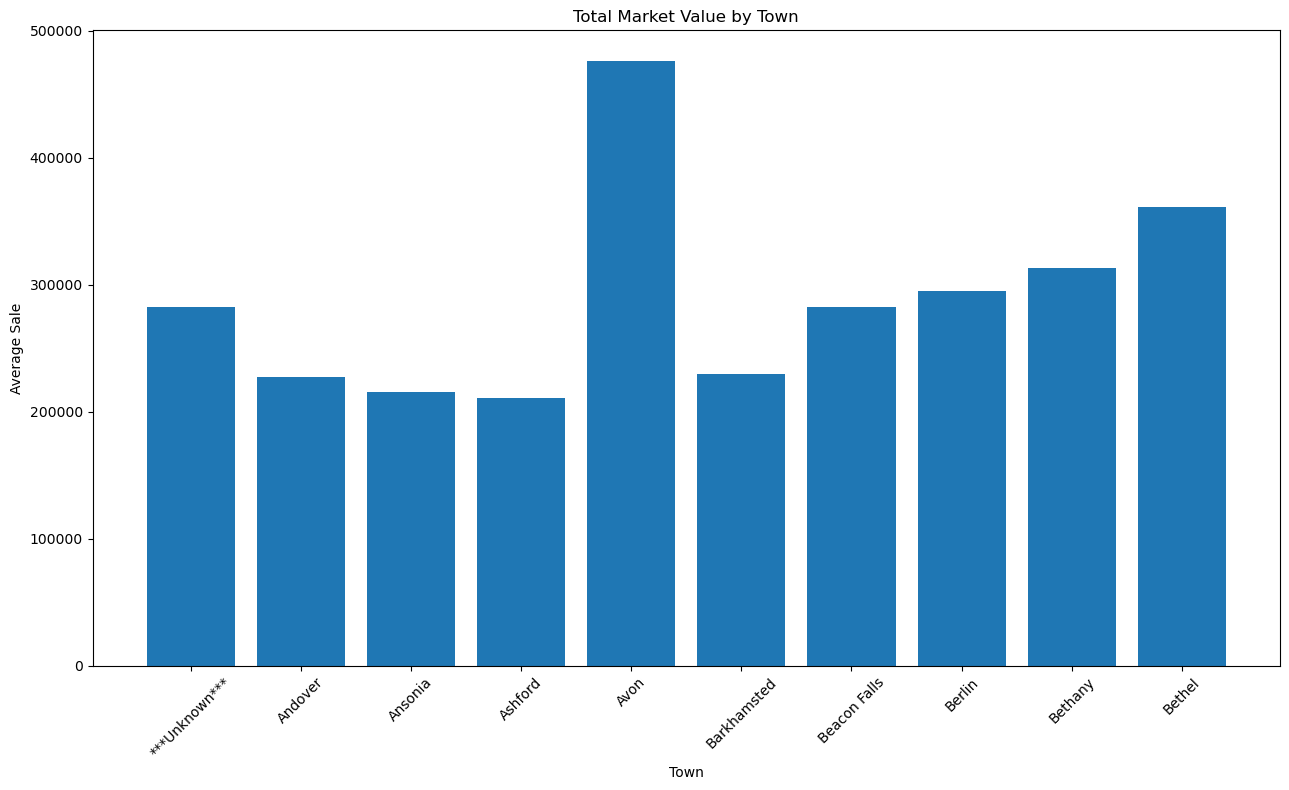

In [111]:
town_analysis = (
    df.groupby('Town')
    .agg(
        Total_Sales=('Sale Amount', 'count'),
        Average_Sale=('Sale Amount', 'mean')
    )
    .reset_index()
    .head(10)
)
    
print(town_analysis)

plt.figure(figsize=(13, 8))

plt.bar(
    town_analysis['Town'],
    town_analysis['Average_Sale']
)

plt.title('Total Market Value by Town')
plt.xlabel('Town')
plt.ylabel('Average Sale')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

   List Year  Property Type  Total_Sales  Total_Market_Value  \
0       2020    Residential        60728        2.911034e+10   
1       2021    Residential        51371        2.256656e+10   
2       2022    Residential        38965        1.943504e+10   
3       2019  Single Family        40518        1.695518e+10   
4       2006  Single Family        30557        1.509534e+10   
5       2014  Single Family        33668        1.307362e+10   
6       2016  Single Family        33955        1.301729e+10   
7       2017  Single Family        31607        1.198245e+10   
8       2018  Single Family        33632        1.151046e+10   
9       2009  Single Family        27694        1.087516e+10   

   Average_Sale_Price  Median_Sale_Price  Average_Assessed_Value  \
0       479356.211359           290000.0           289543.005813   
1       439286.018575           315000.0           227190.544626   
2       498781.999637           325000.0           291313.843552   
3       418460.392319  

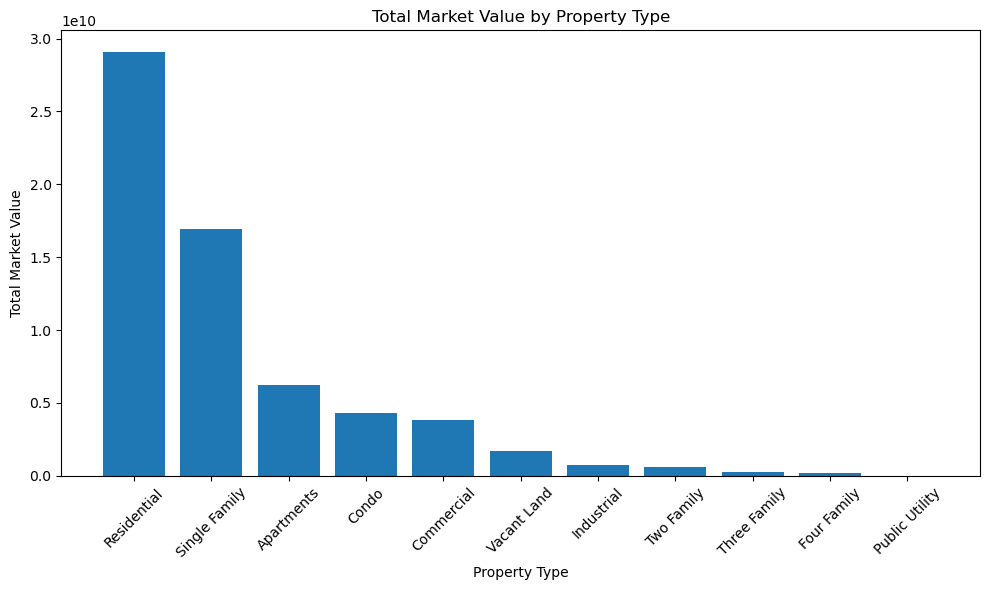

In [112]:
property_analysis = (
    df.groupby(['List Year', 'Property Type'])
    .agg(
        Total_Sales=('Sale Amount', 'count'),
        Total_Market_Value=('Sale Amount', 'sum'),
        Average_Sale_Price=('Sale Amount', 'mean'),
        Median_Sale_Price=('Sale Amount', 'median'),
        Average_Assessed_Value=('Assessed Value', 'mean'),
        Average_Sales_Ratio=('Sales Ratio', 'mean')
    )
    .sort_values('Total_Market_Value', ascending=False)
    .reset_index()
)        
print(property_analysis.head(10))




plt.figure(figsize=(10, 6))

plt.bar(
    property_analysis['Property Type'],
    property_analysis['Total_Market_Value']
)

plt.title('Total Market Value by Property Type')
plt.xlabel('Property Type')
plt.ylabel('Total Market Value')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


     Property Type  Average_Sale  Average_Assessed  Average_Gap  Median_Gap  \
0      Residential     470740.53         268796.12    201944.41    147560.0   
1      Vacant Land     417032.72         117986.11    299046.61     33955.0   
2       Industrial    2238044.56        1116113.14   1121931.42    250250.0   
3     Three Family     179844.52         136715.58     43128.94     33885.0   
4       Apartments    6712885.94        1435347.81   5277538.13    261310.0   
5   Public Utility     213604.40          72475.00    141129.40     16927.0   
6       Commercial    1677886.26        1363012.07    314874.19    120160.0   
7            Condo     260210.99         174558.92     85652.07     53600.0   
8      Four Family     314291.04         186138.94    128152.10     36730.5   
9    Single Family     388514.26         277134.60    111379.66     76230.0   
10      Two Family     199044.61         152584.45     46460.16     35900.0   

    Average_Gap_Percent  
0                 33.64  

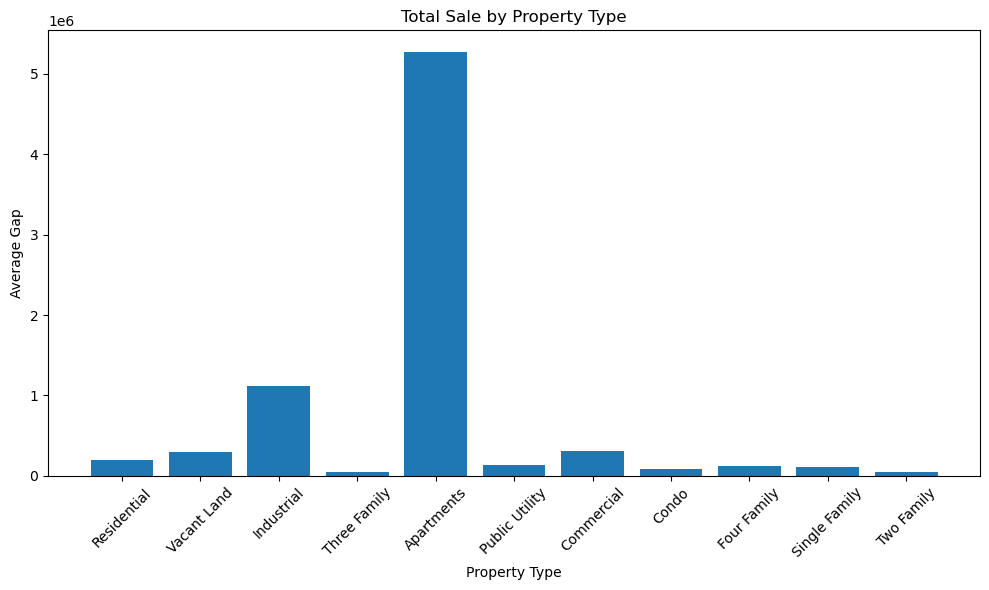

In [113]:
df['Valuation Gap %'] = (
    (df['Sale Amount'] - df['Assessed Value'])
    / df['Sale Amount']
) * 100

df['Valuation Gap'] = (
    df['Sale Amount'] - df['Assessed Value']
)

property_gap = (
    df.groupby('Property Type')
    .agg(
        Average_Sale=('Sale Amount', 'mean'),
        Average_Assessed=('Assessed Value', 'mean'),
        Average_Gap=('Valuation Gap', 'mean'),
        Median_Gap=('Valuation Gap', 'median'),
        Average_Gap_Percent=('Valuation Gap %', 'mean')
    )
    .sort_values('Average_Gap_Percent', ascending=False)
    .reset_index()
    .round(2)

)
print(property_gap)

plt.figure(figsize=(10, 6))

plt.bar(
    property_gap['Property Type'],
    property_gap['Average_Gap']
)

plt.title('Total Sale by Property Type')
plt.xlabel('Property Type')
plt.ylabel('Average Gap')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()



    Year  Total_Sales  Total_Market_Value  Median_Sale_Price
0   2001        14291        3.178363e+09           154900.0
1   2002        60207        1.560357e+10           170000.0
2   2003        56317        1.720434e+10           189900.0
3   2004        73943        2.516201e+10           214250.0
4   2005        79566        3.021333e+10           240000.0
5   2006        57250        2.159822e+10           250000.0
6   2007        46138        2.222218e+10           265000.0
7   2008        34195        1.412136e+10           238000.0
8   2009        36305        1.177615e+10           212000.0
9   2010        39128        1.383911e+10           219000.0
10  2011        32088        1.104590e+10           206041.0
11  2012        32568        1.299903e+10           215000.0
12  2013        37513        1.538165e+10           218000.0
13  2014        41941        1.659346e+10           207500.0
14  2015        48894        1.913221e+10           211000.0
15  2016        47611   

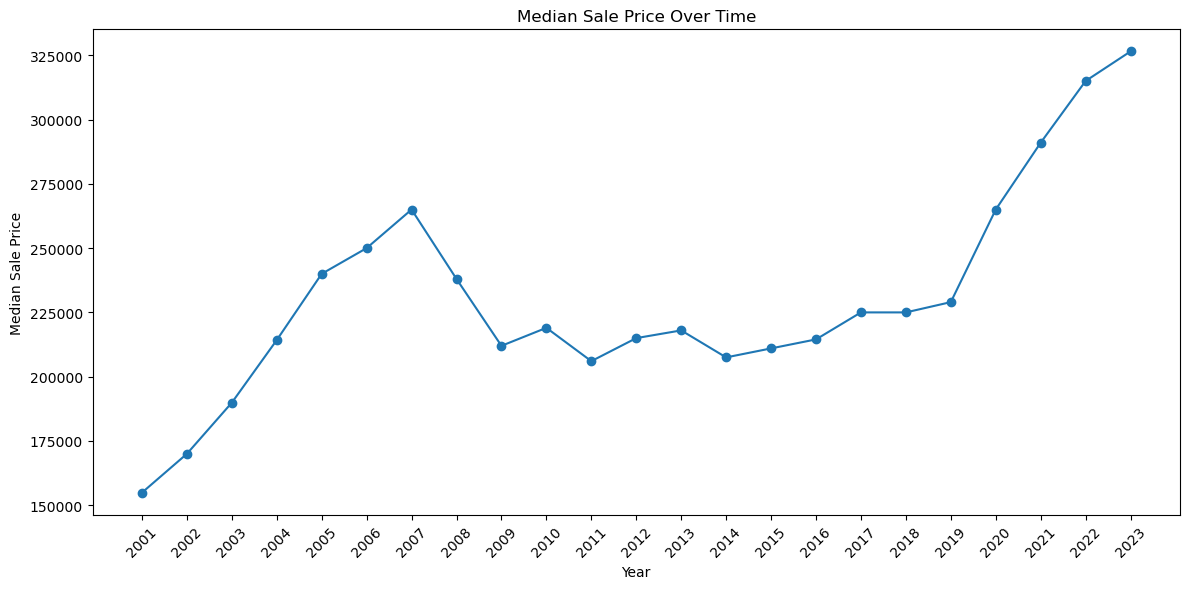

In [114]:

df_clean['Year'] = df_clean['Date Recorded'].dt.year

yearly_analysis = (
    df_clean.groupby('Year')
    .agg(
        Total_Sales=('Sale Amount', 'count'),
        Total_Market_Value=('Sale Amount', 'sum'),
        Median_Sale_Price=('Sale Amount', 'median')
    )
    .reset_index()
)
print(yearly_analysis)


plt.figure(figsize=(12, 6))

plt.plot(
    yearly_analysis['Year'],
    yearly_analysis['Median_Sale_Price'],
    marker='o'
)

plt.title('Median Sale Price Over Time')
plt.xlabel('Year')
plt.ylabel('Median Sale Price')

plt.xticks(yearly_analysis['Year'], rotation=45)
plt.tight_layout()

plt.show()